In [ ]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, r2_score
from scipy.stats import spearmanr
from sklearn.inspection import permutation_importance
from sklearn.model_selection import cross_val_score, GridSearchCV

def load_awards_players_data():
    try:
        awards_players = pd.read_csv('../dataset/awards_players.csv')
        return awards_players

    except FileNotFoundError:
        print("Error: awards_players.csv file not foind in dataset folder!")
        return None

    except Exception as e:
        print(f"Error loading data: {e}")
        return None

def load_coaches_data():
    try:
        coaches = pd.read_csv('../dataset/coaches.csv')
        return coaches

    except FileNotFoundError:
        print("Error: coaches.csv file not foind in dataset folder!")
        return None
    
    except Exception as e:
        print(f"Error loading data: {e}")
        return None

def load_players_teams_data():
    try:
        players_teams = pd.read_csv('../dataset/players_teams.csv')
        return players_teams

    except FileNotFoundError:
        print("Error: players_teams.csv file not foind in dataset folder!")
        return None
    
    except Exception as e:
        print(f"Error loading data {e}")
        return None

def load_players_data():
    try:
        players = pd.read_csv('../dataset/players.csv')
        return players

    except FileNotFoundError:
        print("Error: players.csv file not foind in dataset folder!")
        return None
    
    except Exception as e:
        print(f"Error loading data {e}")
        return None

def load_series_data():
    try:
        series = pd.read_csv('../dataset/series_post.csv')
        
        return series
        
    except FileNotFoundError:
        print("Error: series.csv file not found in dataset folder!")
        return None
    
    except Exception as e:
        print(f"Error loading data: {e}")
        return None   

def load_teams_post_data():
    try:
        teams_post = pd.read_csv('../dataset/teams_post.csv')
        
        return teams_post
        
    except FileNotFoundError:
        print("Error: teams_post.csv file not found in dataset folder!")
        return None
    
    except Exception as e:
        print(f"Error loading data: {e}")
        return None

def load_teams_data():
    try:
        teams = pd.read_csv('../dataset/teams.csv')
        
        return teams
        
    except FileNotFoundError:
        print("Error: teams.csv file not found in dataset folder!")
        return None
    
    except Exception as e:
        print(f"Error loading data: {e}")
        return None


In [3]:
awards_players = load_awards_players_data()
coaches = load_coaches_data()
players_teams = load_players_teams_data()
players = load_players_data()
series_data = load_series_data()
teams_post_data = load_teams_post_data()
teams_data = load_teams_data()


In [ ]:
team_to_franch_mapping = teams_data.set_index('tmID')['franchID'].to_dict()
print(team_to_franch_mapping)

players_teams['tmID'] = players_teams['tmID'].map(team_to_franch_mapping)

coaches['tmID'] = coaches['tmID'].map(team_to_franch_mapping)

teams_data['tmID'] = teams_data['tmID'].map(team_to_franch_mapping)
teams_data.head(134)


{'ATL': 'ATL', 'CHA': 'CHA', 'CHI': 'CHI', 'CLE': 'CLE', 'CON': 'CON', 'DET': 'DET', 'HOU': 'HOU', 'IND': 'IND', 'LAS': 'LAS', 'MIA': 'MIA', 'MIN': 'MIN', 'NYL': 'NYL', 'ORL': 'CON', 'PHO': 'PHO', 'POR': 'POR', 'SAC': 'SAC', 'SAS': 'SAS', 'SEA': 'SEA', 'UTA': 'SAS', 'WAS': 'WAS'}


,year,lgID,tmID,franchID,confID,divID,rank,playoff,seeded,firstRound,...,GP,homeW,homeL,awayW,awayL,confW,confL,min,attend,arena
0,9,WNBA,ATL,ATL,EA,NaN,7,N,0,NaN,...,34,1,16,3,14,2,18,6825,141379,Philips Arena
1,10,WNBA,ATL,ATL,EA,NaN,2,Y,0,L,...,34,12,5,6,11,10,12,6950,120737,Philips Arena
2,1,WNBA,CHA,CHA,EA,NaN,8,N,0,NaN,...,32,5,11,3,13,5,16,6475,90963,Charlotte Coliseum
3,2,WNBA,CHA,CHA,EA,NaN,4,Y,0,W,...,32,11,5,7,9,15,6,6500,105525,Charlotte Coliseum
4,3,WNBA,CHA,CHA,EA,NaN,2,Y,0,L,...,32,11,5,7,9,12,9,6450,106670,Charlotte Coliseum
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
129,1,WNBA,SAS,SAS,WE,NaN,5,N,0,NaN,...,32,12,4,6,10,13,8,6400,103442,EnergySolutions Arena
130,2,WNBA,SAS,SAS,WE,NaN,3,Y,0,L,...,32,9,7,10,6,11,10,6475,110507,EnergySolutions Arena
131,3,WNBA,SAS,SAS,WE,NaN,3,Y,0,W,...,32,12,4,8,8,12,9,6450,118720,EnergySolutions Arena
132,1,WNBA,WAS,WAS,EA,NaN,4,Y,0,L,...,32,7,9,7,9,13,8,6400,244134,Verizon Center


lost        0.869440
confL       0.861650
homeL       0.781505
awayL       0.742283
d_blk       0.266284
d_asts      0.205236
d_ftm       0.166292
d_fta       0.147071
o_pf        0.130553
d_stl       0.117595
d_pts       0.111783
d_fgm       0.097489
d_dreb      0.089654
o_to        0.077820
d_reb       0.065357
d_oreb     -0.014061
o_3pa      -0.052629
o_oreb     -0.053003
d_3pm      -0.054407
d_to       -0.070871
o_3pm      -0.117247
year       -0.119087
o_fga      -0.128011
min        -0.129498
GP         -0.142208
o_fta      -0.163606
d_pf       -0.165619
d_fga      -0.172235
attend     -0.192151
o_stl      -0.193651
d_3pa      -0.221364
o_ftm      -0.230563
o_blk      -0.248392
o_reb      -0.325513
o_pts      -0.331363
o_fgm      -0.339845
o_dreb     -0.385275
o_asts     -0.449623
awayW      -0.775317
homeW      -0.797081
confW      -0.851473
won        -0.896448
divID            NaN
seeded           NaN
tmORB            NaN
tmDRB            NaN
tmTRB            NaN
opptmORB     

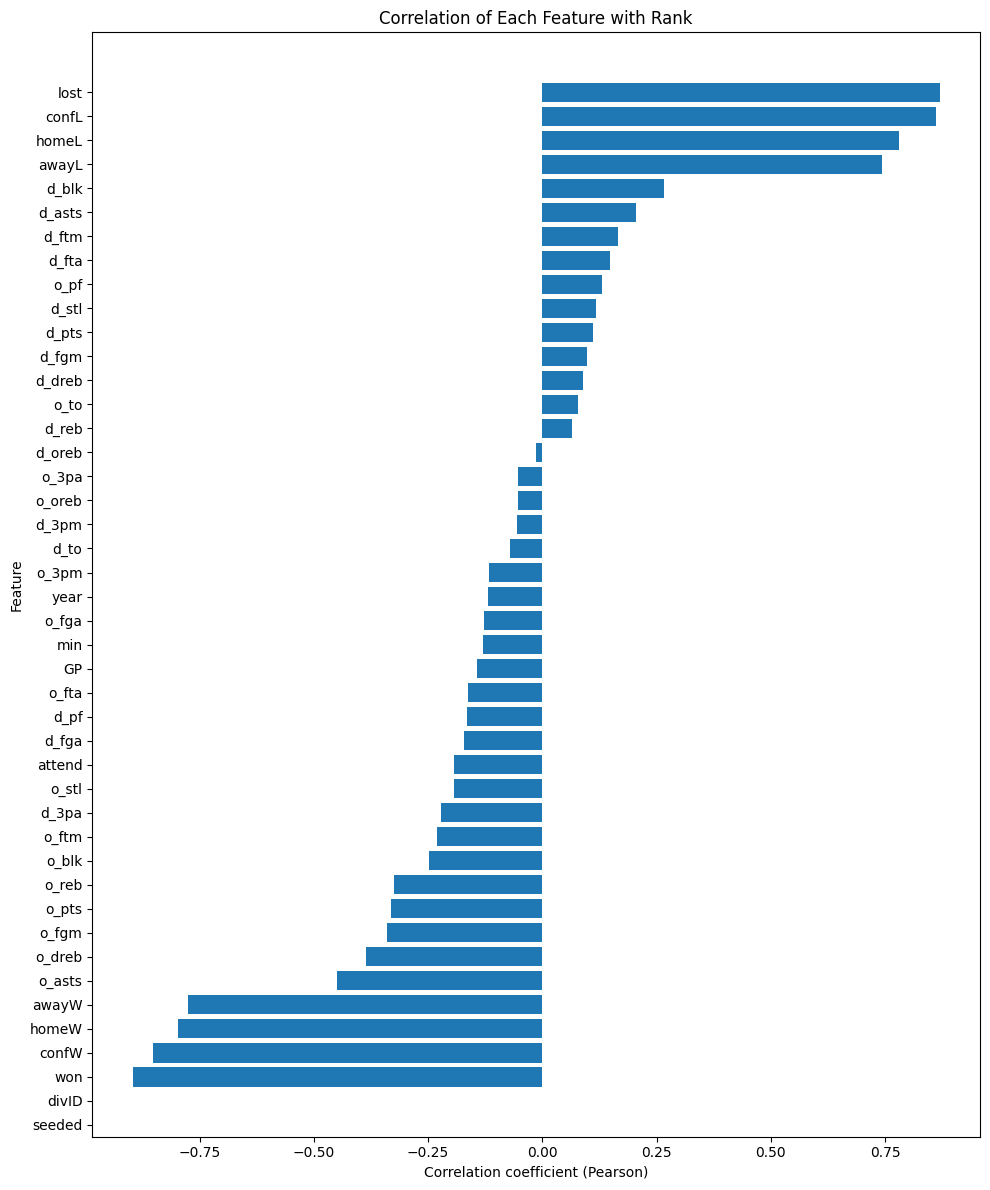

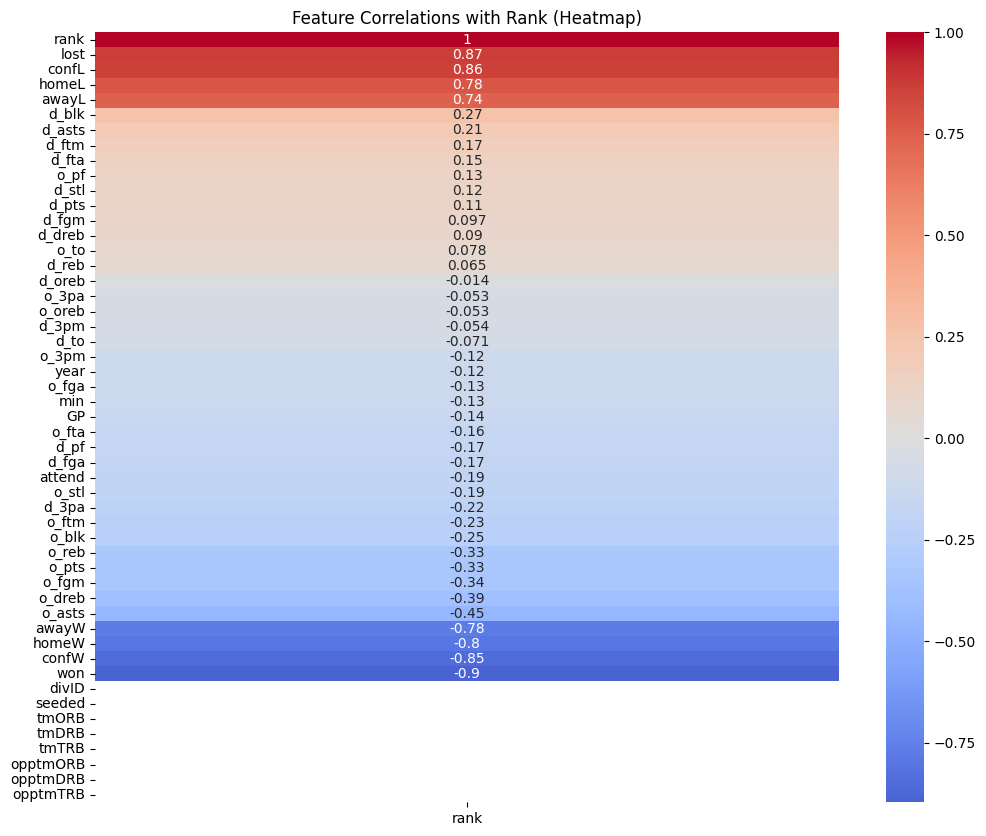

In [ ]:
numeric_teams_data = teams_data.select_dtypes(include=['number'])

correlation = numeric_teams_data.corr()['rank'].drop('rank').sort_values(ascending=False)

print(correlation)

plt.figure(figsize=(10, 12))
plt.barh(correlation.index, correlation.values)
plt.title("Correlation of Each Feature with Rank")
plt.xlabel("Correlation coefficient (Pearson)")
plt.ylabel("Feature")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 10))
sns.heatmap(numeric_teams_data.corr()[['rank']].sort_values(by='rank', ascending=False), 
            annot=True, cmap='coolwarm', center=0)
plt.title("Feature Correlations with Rank (Heatmap)")
plt.show()


Correlation of player-level aggregated features with team rank:
GP                    0.139413
PF                    0.106297
dq                    0.055881
turnovers             0.050104
threeAttempted       -0.039276
oRebounds            -0.092506
threeMade            -0.103862
year                 -0.119087
minutes              -0.121281
fgAttempted          -0.140815
GS                   -0.150719
ftAttempted          -0.182206
steals               -0.183212
ftMade               -0.241107
blocks               -0.248440
points               -0.332464
fgMade               -0.339123
rebounds             -0.346411
dRebounds            -0.405965
assists              -0.447340
PostDQ               -0.461940
PostBlocks           -0.744006
PostthreeMade        -0.746969
PostthreeAttempted   -0.774767
PostftMade           -0.784441
PostftAttempted      -0.789795
PostfgMade           -0.795285
PostPoints           -0.796324
PostdRebounds        -0.799098
PostAssists          -0.800401
PostSt

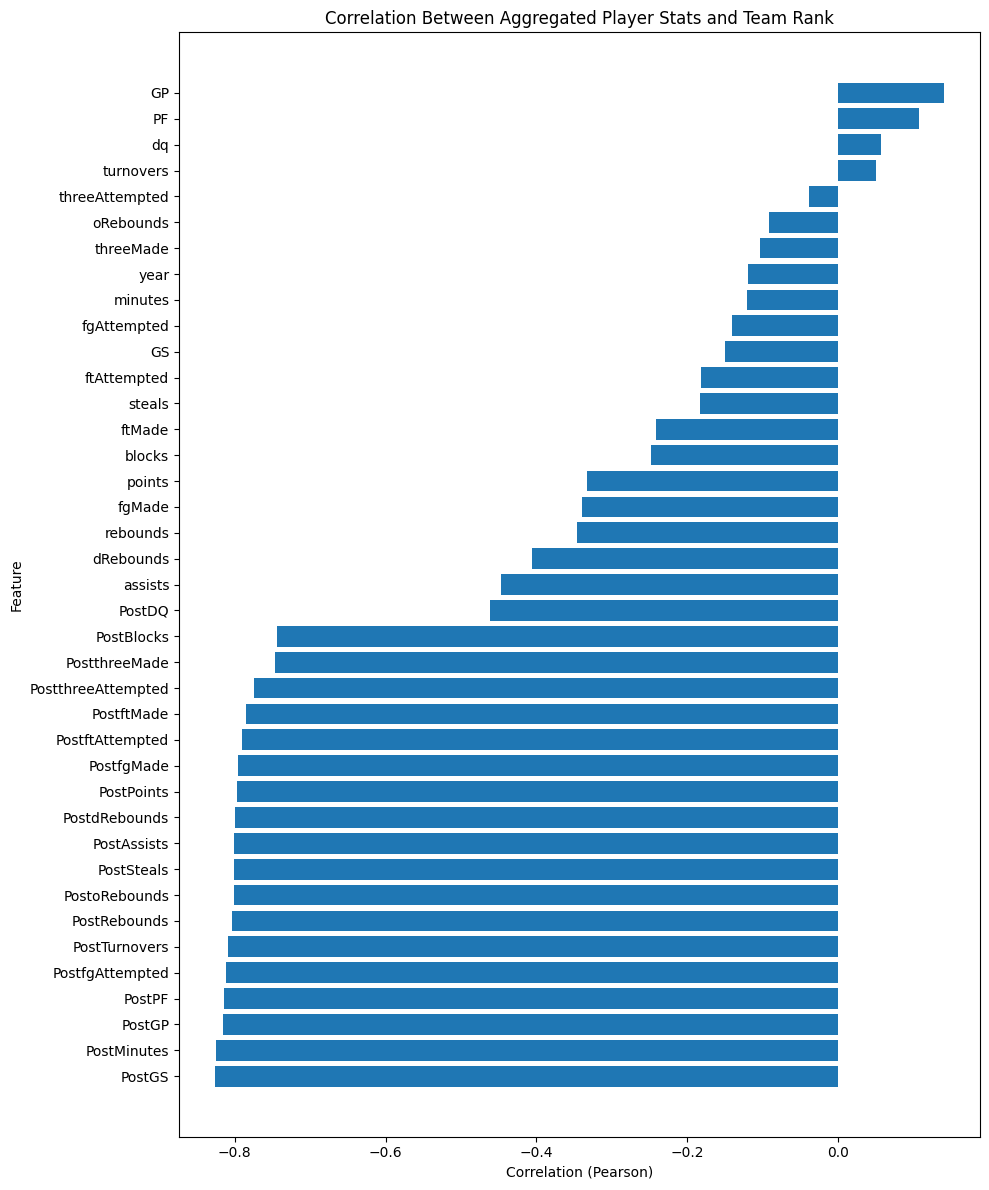

In [ ]:
agg_players = players_teams.groupby(['tmID', 'year']).agg({
    "GP": 'sum',
    "GS": 'sum',
    "minutes": 'sum',
    "points": 'sum',
    "oRebounds": 'sum',
    "dRebounds": 'sum',
    "rebounds": 'sum',
    "assists": 'sum',
    "steals": 'sum',
    "blocks": 'sum',
    "turnovers": 'sum',
    "PF": 'sum',
    "fgAttempted": 'sum',
    "fgMade": 'sum',
    "ftAttempted": 'sum',
    "ftMade": 'sum',
    "threeAttempted": 'sum',
    "threeMade": 'sum',
    "dq": 'sum',
    "PostGP": 'sum',
    "PostGS": 'sum',
    "PostMinutes": 'sum',
    "PostPoints": 'sum',
    "PostoRebounds": 'sum',
    "PostdRebounds": 'sum',
    "PostRebounds": 'sum',
    "PostAssists": 'sum',
    "PostSteals": 'sum',
    "PostBlocks": 'sum',
    "PostTurnovers": 'sum',
    "PostPF": 'sum',
    "PostfgAttempted": 'sum',
    "PostfgMade": 'sum',
    "PostftAttempted": 'sum',
    "PostftMade": 'sum',
    "PostthreeAttempted": 'sum',
    "PostthreeMade": 'sum',
    "PostDQ": 'sum'
}).reset_index()

merged = pd.merge(agg_players, teams_data[['tmID', 'year', 'rank']], on=['tmID', 'year'], how='inner')

corr = merged.corr(numeric_only=True)['rank'].drop('rank').sort_values(ascending=False)

print("Correlation of player-level aggregated features with team rank:")
print(corr)

plt.figure(figsize=(10, 12))
plt.barh(corr.index, corr.values)
plt.title("Correlation Between Aggregated Player Stats and Team Rank")
plt.xlabel("Correlation (Pearson)")
plt.ylabel("Feature")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()



Top correlated features with rank:
won                  -0.896448
lost                  0.869440
confL                 0.861650
confW                -0.851473
PostGS               -0.825335
PostMinutes          -0.823926
PostGP               -0.815503
PostPF               -0.814376
PostfgAttempted      -0.811083
PostTurnovers        -0.808297
PostRebounds         -0.803978
PostoRebounds        -0.801117
PostSteals           -0.800845
PostAssists          -0.800401
PostdRebounds        -0.799098
homeW                -0.797081
PostPoints           -0.796324
PostfgMade           -0.795285
PostftAttempted      -0.789795
PostftMade           -0.784441
homeL                 0.781505
awayW                -0.775317
PostthreeAttempted   -0.774767
PostthreeMade        -0.746969
PostBlocks           -0.744006
awayL                 0.742283
PostDQ               -0.461940
o_asts               -0.449623
assists              -0.447340
dRebounds            -0.405965
o_dreb               -0.385275
reb

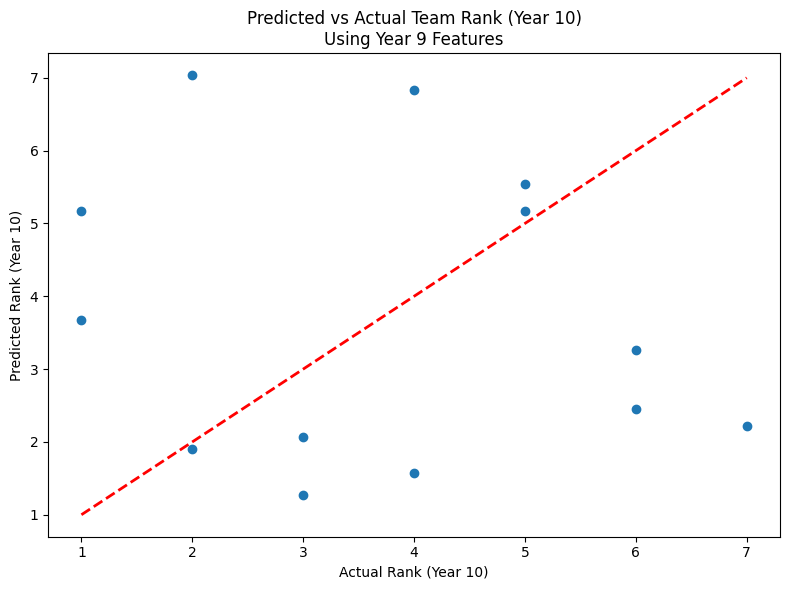

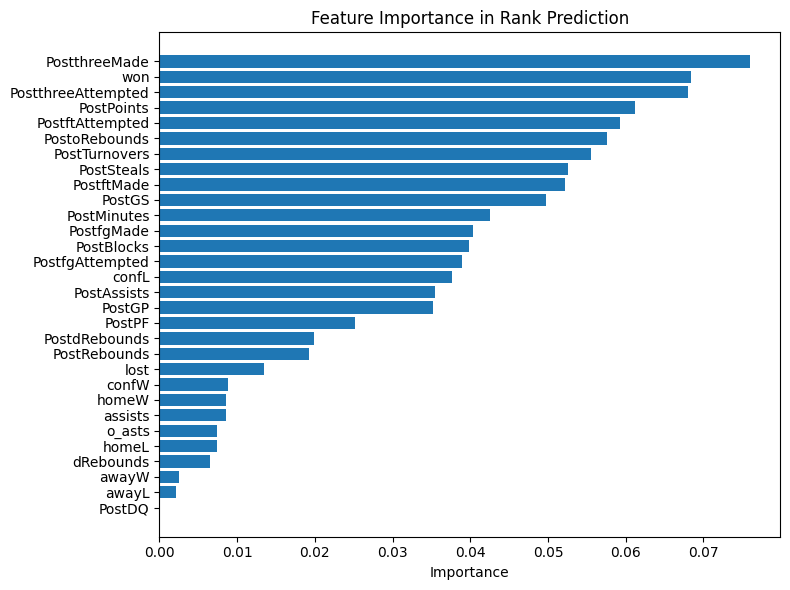

Train MAE: 0.30, Train R²: 0.97
Cross-validated R²: 0.8880909905989579 ± 0.02435405194343579


In [ ]:
team_features = ["o_fgm", "o_fga", "o_ftm", "o_fta", "o_3pm", "o_3pa", "o_oreb", "o_dreb", "o_reb", "o_asts", "o_pf", "o_stl", "o_to",
                "o_blk", "o_pts", "d_fgm", "d_fga", "d_ftm", "d_fta", "d_3pm", "d_3pa", "d_oreb", "d_dreb", "d_reb", "d_asts", "d_pf",
                "d_stl", "d_to", "d_blk", "d_pts", "won", "lost", "GP", "homeW", "homeL", "awayW", "awayL", "confW", "confL"]

teams_subset = teams_data[['tmID', 'year', 'rank'] + team_features]

merged = pd.merge(teams_subset, agg_players, on=['tmID', 'year'], how='inner')

corr = merged.corr(numeric_only=True)['rank'].drop('rank').sort_values(key=abs, ascending=False)
print("\nTop correlated features with rank:")
print(corr.head(40))

top_features = corr.head(26).index.to_list()
print("\nSelected features for training:", top_features)

selected_features = corr[(corr.abs() > 0.4)].index.to_list()
print(f"Selected {len(selected_features)} features with |correlation| > 0.4:")
print(selected_features)

# Train on years 0-8
train = merged[merged['year'] < 9]

# Get year 9 features and year 10 targets
year_9_data = merged[merged['year'] == 9][['tmID'] + selected_features]
year_10_targets = merged[merged['year'] == 10][['tmID', 'rank']]

# Merge and rename for clarity
prediction_data = pd.merge(
    year_9_data, 
    year_10_targets, 
    on='tmID', 
    how='inner',
    suffixes=('_year9', '_year10')
)

# Rename the rank column from year 10 for clarity
prediction_data = prediction_data.rename(columns={'rank': 'actual_rank'})

X_train = train[selected_features]
y_train = train['rank']
X_test = prediction_data[selected_features]
y_test = prediction_data['actual_rank']

model = RandomForestRegressor(n_estimators=200, max_depth=12, min_samples_split=10, min_samples_leaf=1, random_state=42)
model.fit(X_train, y_train)

# Predict rankings for year 10
y_pred = model.predict(X_test)
prediction_data['predicted_rank'] = y_pred

# Evaluate
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"\nModel Performance for Year 10:")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"R² Score: {r2:.2f}")

# Show predicted vs actual
comparison = prediction_data[['tmID', 'actual_rank', 'predicted_rank']].sort_values(by='predicted_rank')
print("\nPredicted vs Actual Rankings for Year 10:")
print(comparison.to_string(index=False))

# Visualize predicted vs actual rank
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual Rank (Year 10)")
plt.ylabel("Predicted Rank (Year 10)")
plt.title("Predicted vs Actual Team Rank (Year 10)\nUsing Year 9 Features")
plt.tight_layout()
plt.show()

importances = pd.Series(model.feature_importances_, index=X_train.columns).sort_values(ascending=True)
plt.figure(figsize=(8,6))
plt.barh(importances.index, importances.values)
plt.title("Feature Importance in Rank Prediction")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

y_train_pred = model.predict(X_train)
mae_train = mean_absolute_error(y_train, y_train_pred)
r2_train = r2_score(y_train, y_train_pred)

print(f"Train MAE: {mae_train:.2f}, Train R²: {r2_train:.2f}")

scores = cross_val_score(model, X_train, y_train, cv=5, scoring='r2')
print("Cross-validated R²:", scores.mean(), "±", scores.std())
